<a href="https://colab.research.google.com/github/SouravDasz/Computer-vision-practice/blob/main/ambulance_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Vf51w6PDloBEGS4kFg6u")
project = rf.workspace("himank-vpetc").project("ambulance-4bova")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Ambulance-1 in yolov8:: 100%|██████████| 12876/12876 [00:02<00:00, 4605.92it/s]


In [2]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

In [5]:
model=YOLO("yolov8n.pt")

In [7]:
model.train(
    data="/content/Ambulance-1/data.yaml",
    epochs=5,
    imgsz=640,
    batch=32,
    device=0,
    lr0=0.01
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Ambulance-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2ba86a71a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [12]:
rusult=model.predict(source="/content/Ambulance-1/valid/images/image_000257_jpg.rf.3bd3eb7d511f3a984deaa8d3e2eb7def.jpg")


image 1/1 /content/Ambulance-1/valid/images/image_000257_jpg.rf.3bd3eb7d511f3a984deaa8d3e2eb7def.jpg: 640x640 1 My First Project - v1 2025-02-17 5-45am, 8.8ms
Speed: 2.0ms preprocess, 8.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


In [15]:
results = model("/content/Ambulance-1/valid/images/image_000247_jpg.rf.d9b0d51770f58bf5af01d8534a8d5755.jpg")
r = results[0]

print(r.boxes.xyxy)   # bounding boxes
print(r.boxes.conf)   # confidence scores
print(r.boxes.cls)    # class indices


image 1/1 /content/Ambulance-1/valid/images/image_000247_jpg.rf.d9b0d51770f58bf5af01d8534a8d5755.jpg: 640x640 1 My First Project - v1 2025-02-17 5-45am, 24.4ms
Speed: 7.4ms preprocess, 24.4ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
tensor([[7.4978e+01, 1.7133e-01, 6.4000e+02, 6.0644e+02]], device='cuda:0')
tensor([0.9099], device='cuda:0')
tensor([0.], device='cuda:0')



image 1/1 /content/images (1).jpg: 384x640 2 My First Project - v1 2025-02-17 5-45ams, 92.8ms
Speed: 10.7ms preprocess, 92.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


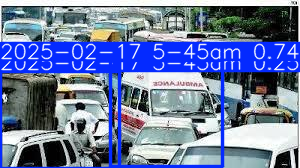

In [21]:
results = model("/content/images (1).jpg")

results[0].show()